# Intensity Transformations & Filtering Spatial Domain

**Name:** Fatimah Saad Alghamdi  
**ID:** 2240002658

## Thresholding

### Setup (Colab-compatible)

In [1]:
# This cell makes the notebook work both in Google Colab and locally.
# - In Colab, cv2_imshow comes from google.colab.patches.
# - Outside Colab, we define a matplotlib-based equivalent with the same name/signature.
try:
    from google.colab.patches import cv2_imshow
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    import matplotlib.pyplot as plt
    import cv2 as _cv2
    def cv2_imshow(img):
        disp = _cv2.cvtColor(img, _cv2.COLOR_BGR2RGB) if img.ndim == 3 else img
        plt.figure()
        plt.imshow(disp, cmap='gray' if img.ndim == 2 else None)
        plt.axis('off')
        plt.show()


In [2]:
# Make sure cameraman.png is available.
# In Colab: if the file isn't already in the working directory, this opens a file picker.
# Locally: it assumes cameraman.png is already alongside this notebook.
import os
if IN_COLAB and not os.path.exists('cameraman.png'):
    from google.colab import files
    uploaded = files.upload()  # select cameraman.png when prompted


Threshold value: 0


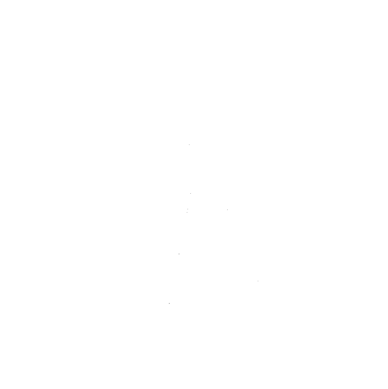

Threshold value: 50


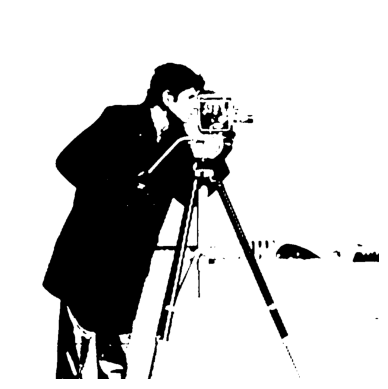

Threshold value: 100


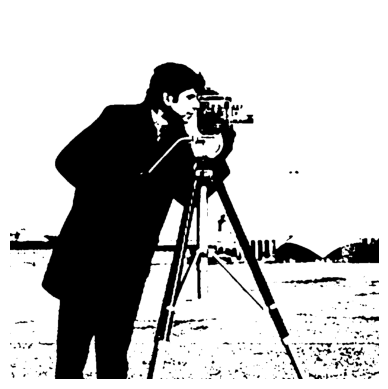

Threshold value: 150


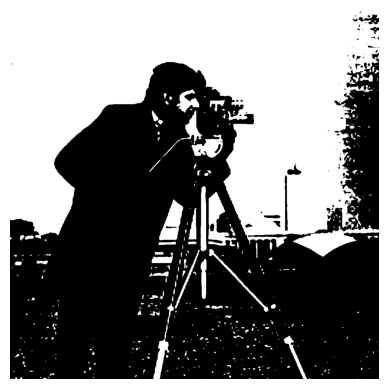

Threshold value: 200


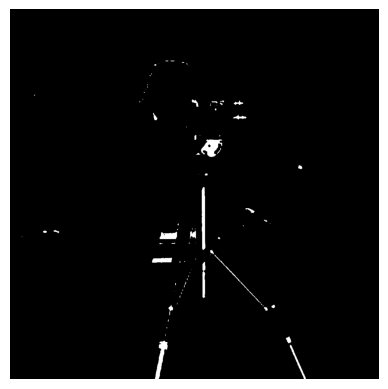

In [3]:
import cv2

# Load the image in grayscale
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret_thresh_value, thresh_img = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)

    print(f"Threshold value: {threshold_value}")
    cv2_imshow(thresh_img)


Original Image: 


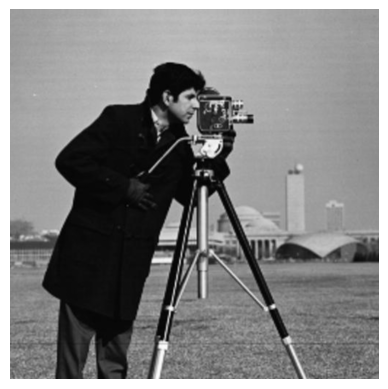

In [4]:
print("Original Image: ")
cv2_imshow(img)


## Histograms

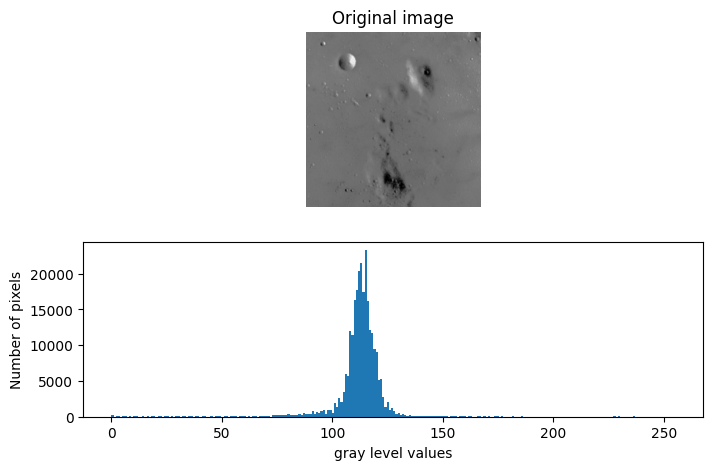

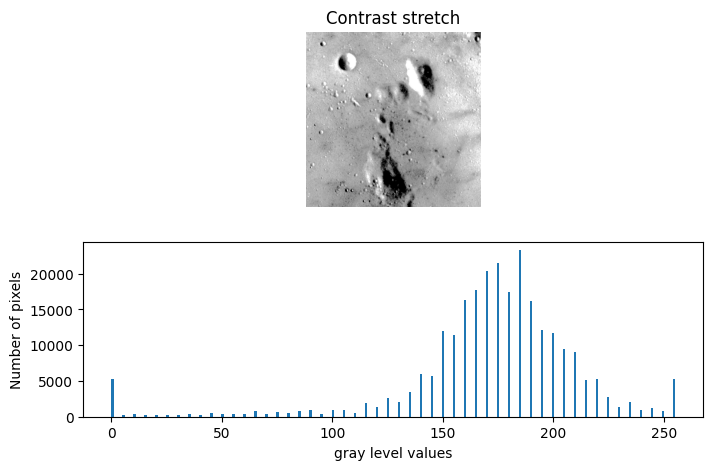

In [5]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage import exposure

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()


# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


### Task 1: Contrast stretching (3rd–80th percentile) on moon image

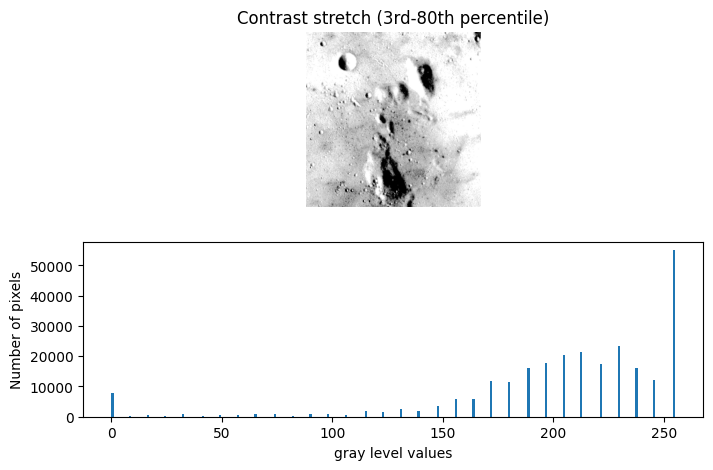

In [6]:
# Task#1: Rescale intensity values using the 3rd and 80th percentiles, and plot the histogram

# Step#1: Use the same moon image
p3, p80 = np.percentile(img, (3, 80))
img_rescale_task1 = exposure.rescale_intensity(img, in_range=(p3, p80))

# Step#2: Display the rescaled image with its histogram
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale_task1, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch (3rd-80th percentile)')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale_task1.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()


### Task 2: Histogram equalization on moon image

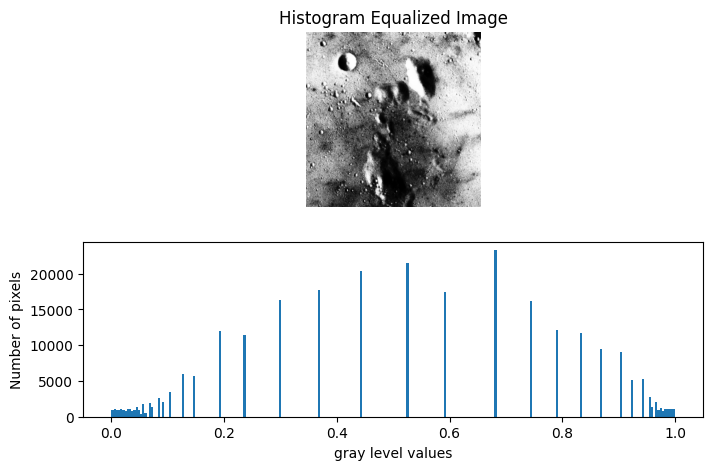

In [7]:
# Task#2: Apply histogram equalization using exposure.equalize_hist and display the image + histogram

img_eq = exposure.equalize_hist(img)

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_eq, cmap = 'gray')
plt.axis('off')
plt.title('Histogram Equalized Image')

fig.add_subplot(2, 1, 2)
# equalize_hist returns float values in [0, 1]
plt.hist(img_eq.flat, bins = 256, range=(0, 1))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()


### Task 3: Histogram matching (rocket as reference, chelsea as source image)

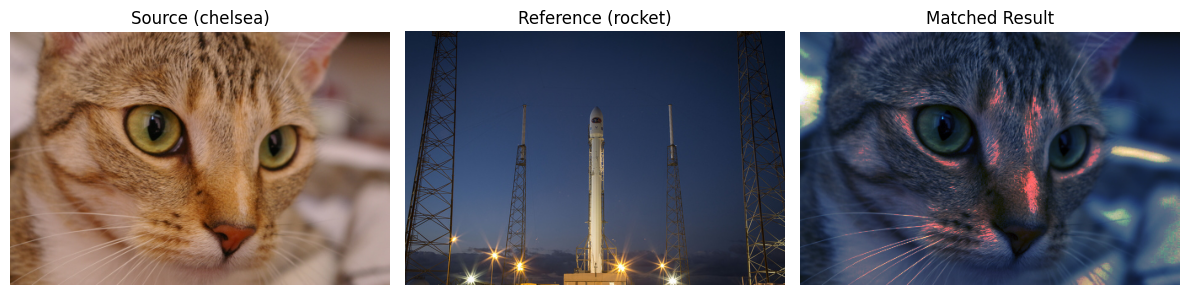

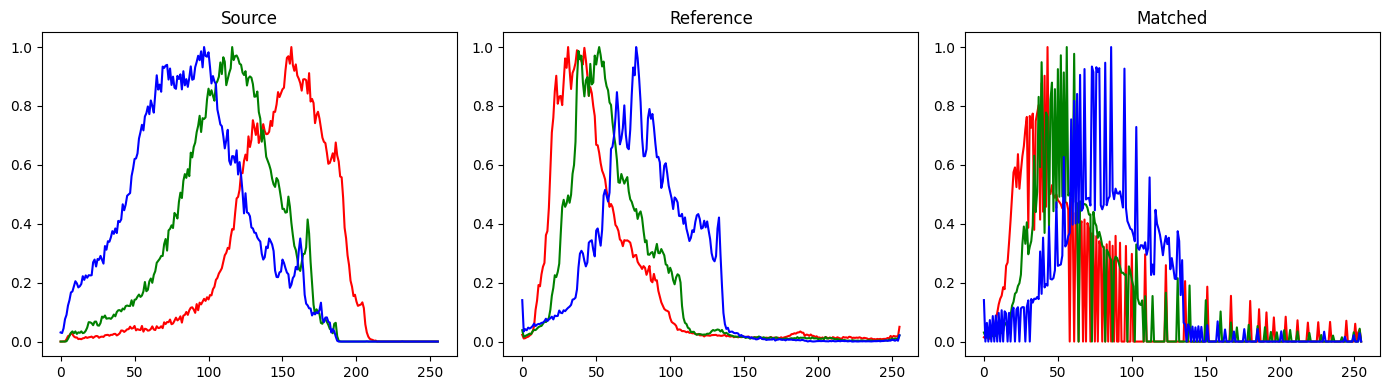

In [8]:
# Task#3: Histogram matching using skimage.data.rocket() as reference and skimage.data.chelsea() as source

reference = data.rocket()
image = data.chelsea()

# Match the histogram of 'image' to that of 'reference' (both are RGB, so use channel_axis=-1)
matched = exposure.match_histograms(image, reference, channel_axis=-1)

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

axes[0].imshow(image)
axes[0].set_title('Source (chelsea)')
axes[0].axis('off')

axes[1].imshow(reference)
axes[1].set_title('Reference (rocket)')
axes[1].axis('off')

axes[2].imshow(matched.astype(np.uint8))
axes[2].set_title('Matched Result')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Optional: compare per-channel histograms before/after matching
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
for i, img_ in enumerate((image, reference, matched)):
    for ch, color_ in enumerate(('red', 'green', 'blue')):
        img_hist, bins = exposure.histogram(img_[..., ch], source_range='dtype')
        axes[i].plot(bins, img_hist / img_hist.max(), color=color_)
axes[0].set_title('Source')
axes[1].set_title('Reference')
axes[2].set_title('Matched')
plt.tight_layout()
plt.show()


# Thank You!